## US-11 · Analisi degli Outlier — Metodo Deviazione Standard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append(os.path.abspath(".."))

# Carica il dataset pulito
df = pd.read_csv(os.path.abspath(os.path.join("..", "data", "processed", "data_clean.csv")))

sns.set_theme(style="whitegrid")
print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")

Dataset caricato: 7043 righe, 37 colonne


In [2]:
# Selezioniamo solo le variabili numeriche continue
# Escludiamo le binarie (0/1) e il target
binarie = [
    'dependents', 'device_protection_plan', 'internet_service',
    'married', 'multiple_lines', 'online_backup', 'online_security',
    'paperless_billing', 'partner', 'phone_service', 'premium_tech_support',
    'referred_a_friend', 'senior_citizen', 'streaming_movies',
    'streaming_music', 'streaming_tv', 'unlimited_data', 'churn'
]

num_cols = [col for col in df.select_dtypes(include='number').columns
            if col not in binarie]

print(f"Variabili numeriche continue analizzate: {len(num_cols)}")
print(num_cols)

Variabili numeriche continue analizzate: 14
['age', 'avg_monthly_gb_download', 'avg_monthly_ld_charges', 'cltv', 'monthly_charge', 'num_dependents', 'num_referrals', 'population', 'tenure_months', 'total_charges', 'total_extra_data_charges', 'total_ld_charges', 'total_refunds', 'total_revenue']


In [3]:
from src.preprocessing import detect_outliers_std

df_outlier_std = detect_outliers_std(df, num_cols)
display(df_outlier_std)

,Variabile,Media,Dev. Std.,Limite inferiore,Limite superiore,N. Outlier,% Outlier
12,total_refunds,1.96,7.90,-21.75,25.67,266,3.78
10,total_extra_data_charges,6.86,25.10,-68.45,82.18,259,3.68
1,avg_monthly_gb_download,20.52,20.42,-40.74,81.77,91,1.29
11,total_ld_charges,749.10,846.66,-1790.88,3289.08,58,0.82
7,population,22139.60,21152.39,-41317.58,85596.78,57,0.81
5,num_dependents,0.47,0.96,-2.42,3.36,26,0.37
13,total_revenue,3034.38,2865.20,-5561.23,11629.99,5,0.07
6,num_referrals,1.95,3.00,-7.05,10.96,2,0.03
2,avg_monthly_ld_charges,22.96,15.45,-23.39,69.30,0,0.00
0,age,46.51,16.75,-3.74,96.76,0,0.00


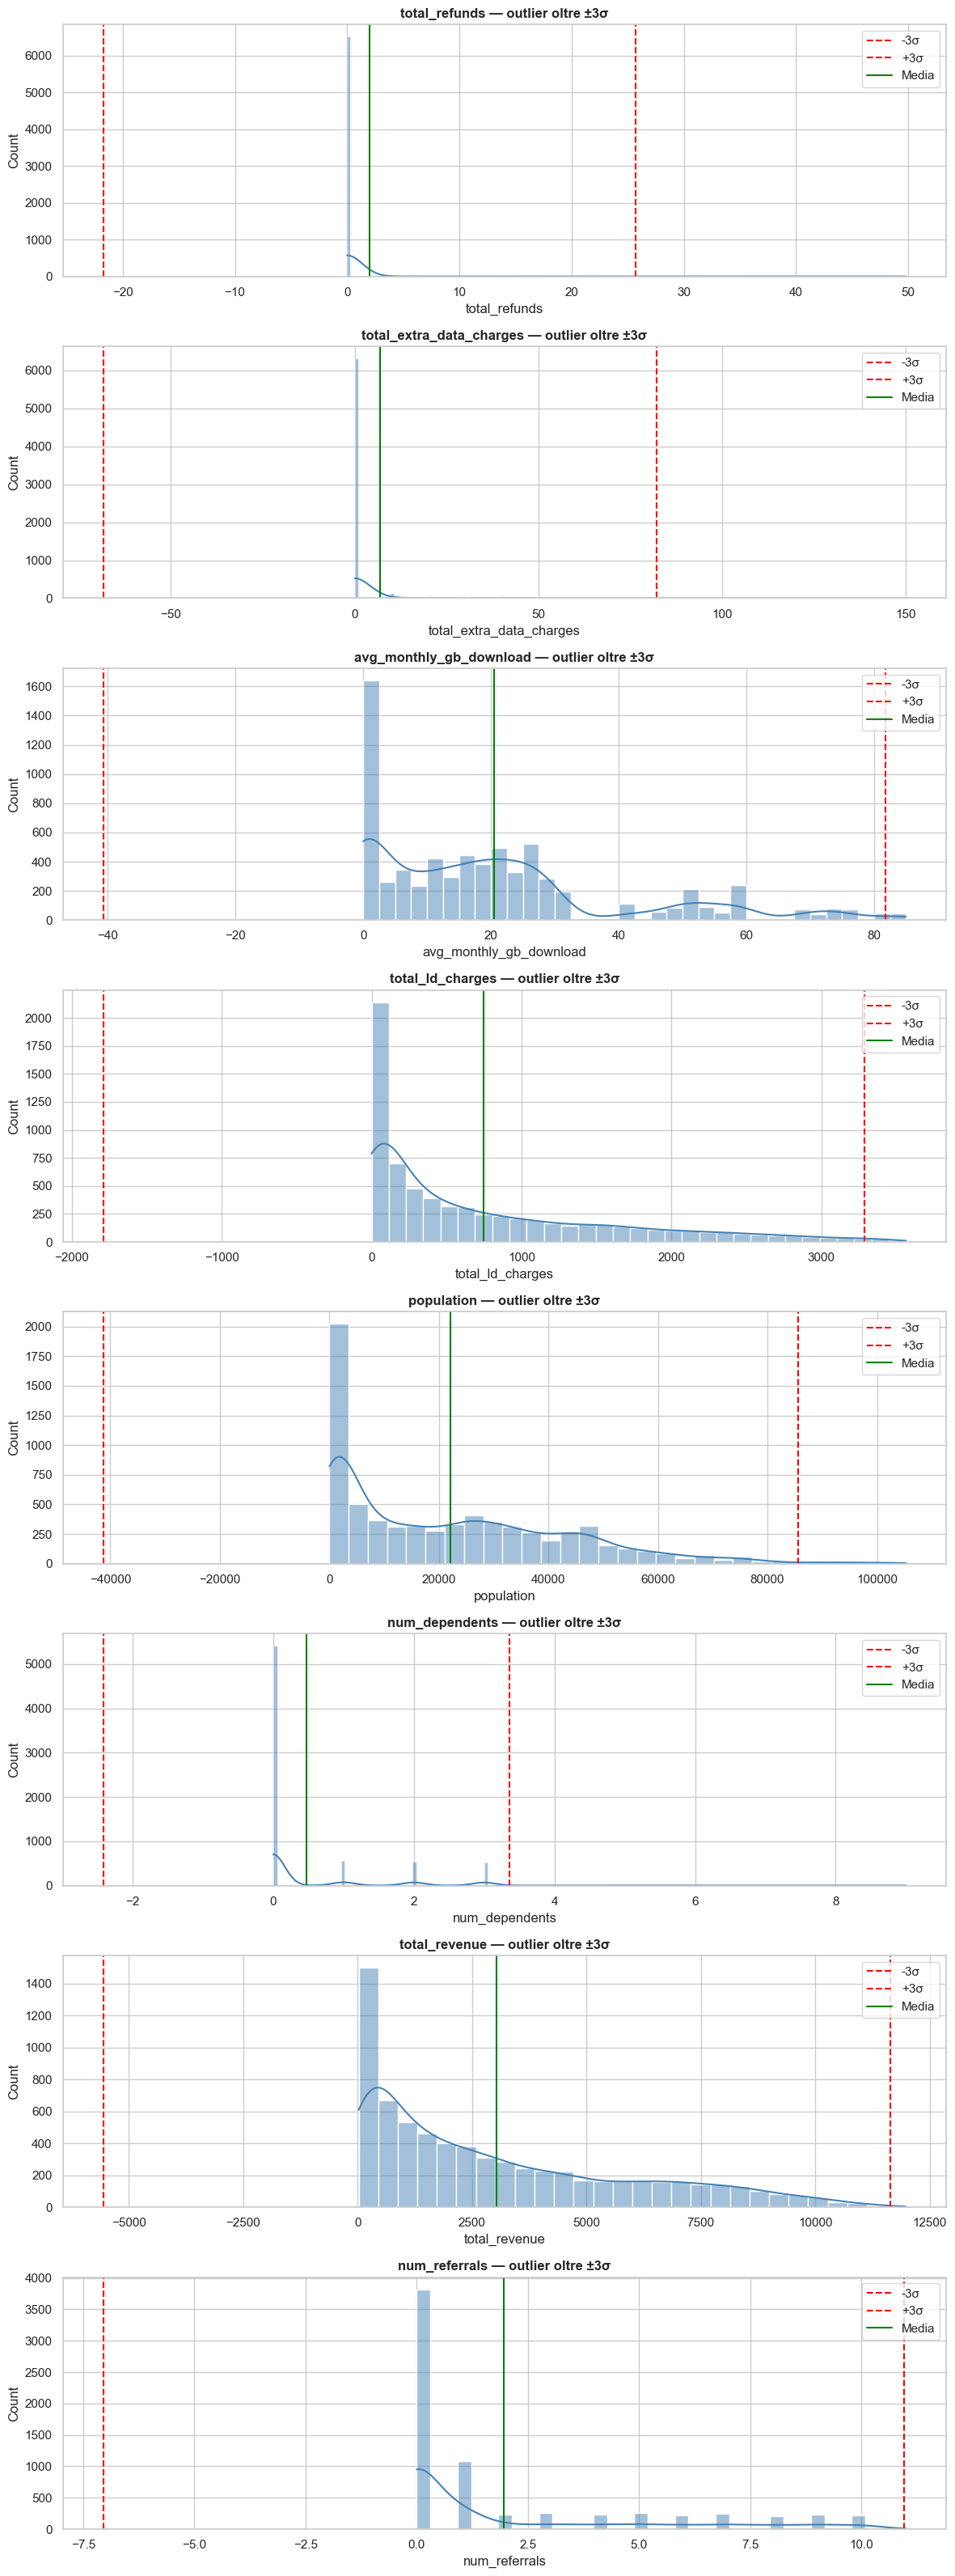

✅ Grafico salvato in: /Users/antoniohopee/Desktop/projects/telco-churn-ml/outputs/figures/us11_outlier_std.png


In [4]:
# Visualizziamo solo le variabili con almeno 1 outlier
cols_con_outlier = df_outlier_std[df_outlier_std['N. Outlier'] > 0]['Variabile'].tolist()

fig, axes = plt.subplots(len(cols_con_outlier), 1, figsize=(12, 4 * len(cols_con_outlier)))

for ax, col in zip(axes, cols_con_outlier):
    media = df[col].mean()
    std = df[col].std()
    
    sns.histplot(data=df, x=col, kde=True, ax=ax, color='steelblue')
    
    # Linee dei limiti ±3σ
    ax.axvline(media - 3 * std, color='red', linestyle='--', label='-3σ')
    ax.axvline(media + 3 * std, color='red', linestyle='--', label='+3σ')
    ax.axvline(media, color='green', linestyle='-', label='Media')
    
    ax.set_title(f'{col} — outlier oltre ±3σ', fontweight='bold')
    ax.legend()

plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us11_outlier_std.png"))
plt.savefig(figures_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Grafico salvato in: {figures_path}")

### Osservazioni US-11 — Outlier con Deviazione Standard

**Variabili con outlier rilevati:**

| Variabile | N. Outlier | % | Valutazione |
|---|---|---|---|
| `total_refunds` | 266 | 3.78% | Plausibili — la maggior parte dei clienti ha rimborsi vicini a zero, pochi hanno rimborsi elevati. Distribuzione asimmetrica attesa. |
| `total_extra_data_charges` | 259 | 3.68% | Plausibili — la maggior parte paga 0€ di extra dati, pochi heavy user hanno costi elevati. |
| `avg_monthly_gb_download` | 91 | 1.29% | Plausibili — clienti con consumi dati molto alti (>81 GB/mese), probabilmente con piano illimitato. |
| `total_ld_charges` | 58 | 0.82% | Plausibili — clienti con molte chiamate internazionali. |
| `population` | 57 | 0.81% | Plausibili — alcune città californiane hanno popolazioni molto alte. |
| `num_dependents` | 26 | 0.37% | Plausibili — famiglie numerose, raro ma possibile. |
| `total_revenue` | 5 | 0.07% | Plausibili — clienti con tenure molto alta e canone elevato. |
| `num_referrals` | 2 | 0.03% | Plausibili — clienti molto fidelizzati che raccomandano spesso il servizio. |

**Variabili senza outlier:**
`age`, `monthly_charge`, `tenure_months`, `total_charges`, `cltv` — 
nessun valore oltre ±3σ. I range sono coerenti con il contesto reale.

**⚠️ Limite del metodo:**
Il metodo ±3σ produce limiti inferiori negativi per variabili come 
`total_refunds`, `total_extra_data_charges` e `total_revenue`. 
Valori negativi sono impossibili per queste variabili — è un artefatto 
matematico del metodo, che non tiene conto dei vincoli reali del dominio.
Questo limite sarà confrontato con il metodo IQR nella US-12, 
che gestisce meglio le distribuzioni asimmetriche.

**Conclusione generale:**
Nessun outlier è stato identificato come errore di inserimento dati. 
Tutti i valori anomali hanno una spiegazione plausibile nel contesto 
di una compagnia telefonica. Non verranno rimossi in questa fase —
la decisione finale verrà presa dopo il confronto con gli altri metodi.

## US-12 · Analisi degli Outlier — Metodo Boxplot (IQR)

Il metodo IQR (Interquartile Range) identifica gli outlier usando i quartili.
Un valore è outlier se:
- Inferiore a Q1 − 1.5 × IQR
- Superiore a Q3 + 1.5 × IQR

A differenza del metodo ±3σ, l'IQR non assume una distribuzione normale
ed è più robusto su distribuzioni asimmetriche come quelle che abbiamo nel dataset.

In [9]:
# Importa e usa la funzione da src/preprocessing.py
from src.preprocessing import detect_outliers_iqr

df_outlier_iqr = detect_outliers_iqr(df, num_cols)
display(df_outlier_iqr)

,Variabile,Q1,Q3,IQR,Limite inferiore,Limite superiore,N. Outlier,% Outlier
5,num_dependents,0.00,0.00,0.00,0.00,0.00,1627,23.10
10,total_extra_data_charges,0.00,0.00,0.00,0.00,0.00,728,10.34
6,num_referrals,0.00,3.00,3.00,-4.50,7.50,676,9.60
12,total_refunds,0.00,0.00,0.00,0.00,0.00,525,7.45
1,avg_monthly_gb_download,3.00,27.00,24.00,-33.00,63.00,362,5.14
11,total_ld_charges,70.54,1191.10,1120.55,-1610.29,2871.93,196,2.78
7,population,2344.00,36125.00,33781.00,-48327.50,86796.50,57,0.81
13,total_revenue,605.61,4801.15,4195.54,-5687.69,11094.45,21,0.30
2,avg_monthly_ld_charges,9.21,36.39,27.18,-31.57,77.17,0,0.00
0,age,32.00,60.00,28.00,-10.00,102.00,0,0.00


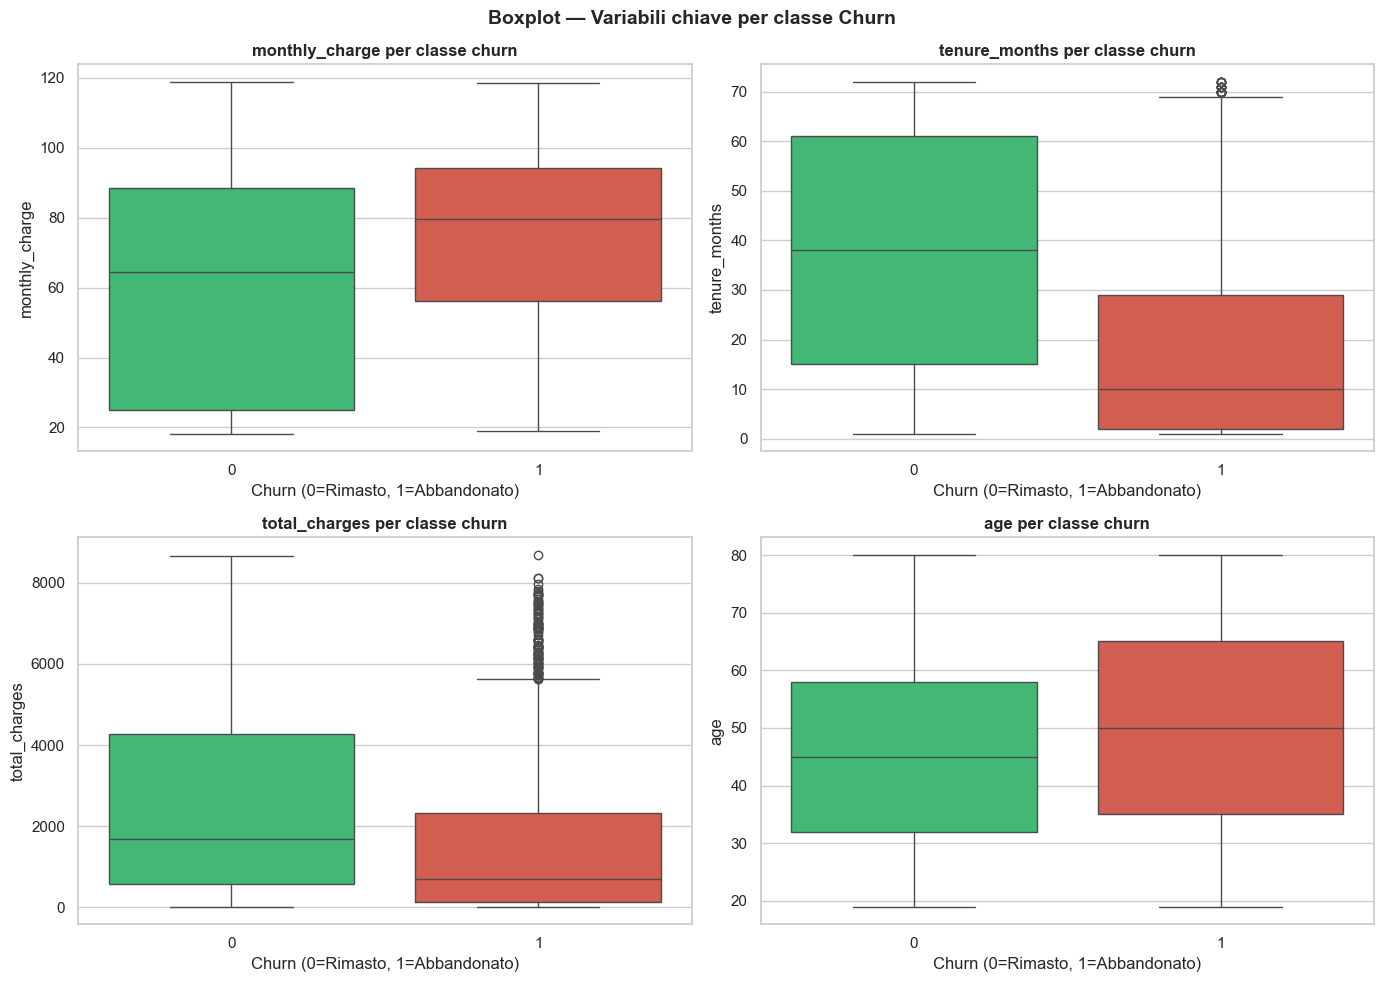

✅ Grafico salvato in: /Users/antoniohopee/Desktop/projects/telco-churn-ml/outputs/figures/us12_boxplot_churn.png


In [10]:
# Visualizziamo i boxplot per le 4 variabili più rilevanti
# separati per classe churn
cols_boxplot = ['monthly_charge', 'tenure_months', 'total_charges', 'age']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_boxplot):
    sns.boxplot(
        data=df,
        x='churn',
        y=col,
        hue='churn',
        palette={0: '#2ecc71', 1: '#e74c3c'},
        ax=ax,
        legend=False
    )
    ax.set_title(f'{col} per classe churn', fontweight='bold')
    ax.set_xlabel('Churn (0=Rimasto, 1=Abbandonato)')
    ax.set_ylabel(col)

plt.suptitle('Boxplot — Variabili chiave per classe Churn', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

figures_path = os.path.abspath(os.path.join("..", "outputs", "figures", "us12_boxplot_churn.png"))
plt.savefig(figures_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Grafico salvato in: {figures_path}")

## Analisi US-12
`monthly_charge`: I clienti churned (rosso) hanno un canone mensile mediano più alto (~80€) rispetto a chi rimane (verde, ~64€). Le due box si sovrappongono molto — il canone da solo non basta a predire il churn, ma è un segnale.

`tenure_months`: Questo è il grafico più potente di tutti. I clienti churned hanno una tenure mediana bassissima (~9 mesi) contro i ~38 mesi di chi rimane. La box rossa è tutta schiacciata in basso — chi abbandona lo fa presto. Noterai anche due piccoli cerchi in alto nel grafico rosso — sono outlier IQR, clienti con tenure insolitamente alta che però hanno comunque abbandonato.

`total_charges`: I clienti churned hanno un totale addebitato molto basso (mediana ~600€) rispetto a chi rimane (~1.700€). Coerente con la tenure bassa — se sei cliente da poco hai speso poco in totale. Noterai molti cerchi sopra il baffo superiore rosso — sono outlier IQR, clienti churned con spesa totale insolitamente alta.

`age`: Le due box si sovrappongono quasi completamente — i clienti churned sono leggermente più anziani (mediana ~50 anni vs ~45) ma la differenza è minima. L'età da sola è una variabile poco discriminante, come avevamo già visto in US-08.

In [7]:
# Tabella comparativa tra metodo deviazione standard e metodo IQR
confronto = df_outlier_std[['Variabile', 'N. Outlier', '% Outlier']].copy()
confronto.columns = ['Variabile', 'N. Outlier (±3σ)', '% Outlier (±3σ)']

iqr_cols = df_outlier_iqr[['Variabile', 'N. Outlier', '% Outlier']].copy()
iqr_cols.columns = ['Variabile', 'N. Outlier (IQR)', '% Outlier (IQR)']

confronto = confronto.merge(iqr_cols, on='Variabile')
confronto = confronto.sort_values('N. Outlier (IQR)', ascending=False)

display(confronto)

,Variabile,N. Outlier (±3σ),% Outlier (±3σ),N. Outlier (IQR),% Outlier (IQR)
5,num_dependents,26,0.37,1627,23.10
1,total_extra_data_charges,259,3.68,728,10.34
7,num_referrals,2,0.03,676,9.60
0,total_refunds,266,3.78,525,7.45
2,avg_monthly_gb_download,91,1.29,362,5.14
3,total_ld_charges,58,0.82,196,2.78
4,population,57,0.81,57,0.81
6,total_revenue,5,0.07,21,0.30
8,avg_monthly_ld_charges,0,0.00,0,0.00
9,age,0,0.00,0,0.00


### Osservazioni US-12 — Confronto IQR vs Deviazione Standard

**Differenze principali tra i due metodi:**

| Variabile | ±3σ | IQR | Spiegazione |
|---|---|---|---|
| `num_dependents` | 26 (0.37%) | 1.627 (23.1%) | IQR = 0 — più del 50% dei clienti ha 0 dipendenti, qualsiasi valore positivo diventa outlier |
| `total_extra_data_charges` | 259 (3.68%) | 728 (10.34%) | IQR = 0 — stessa situazione, la maggior parte paga 0€ di extra dati |
| `total_refunds` | 266 (3.78%) | 525 (7.45%) | IQR = 0 — la maggior parte ha 0€ di rimborsi |
| `num_referrals` | 2 (0.03%) | 676 (9.60%) | IQR molto sensibile alla distribuzione asimmetrica |
| `population` | 57 (0.81%) | 57 (0.81%) | Unica variabile dove i due metodi concordano perfettamente |

**Quale metodo è migliore?**

Non esiste una risposta assoluta — dipende dalla distribuzione:
- **±3σ** funziona bene su distribuzioni simmetriche e normali
- **IQR** è più robusto su distribuzioni asimmetriche, ma produce 
  risultati fuorvianti quando IQR = 0 (variabili con molti zeri)

**⚠️ Limite critico dell'IQR su questo dataset:**
Per variabili come `num_dependents`, `total_extra_data_charges` e `total_refunds`
l'IQR = 0 rende il metodo inutilizzabile — identifica come outlier il 23% dei clienti,
il che non ha senso pratico. In questi casi il metodo ±3σ è più affidabile.

**Conclusione:**
Nessun outlier verrà rimosso in questa fase. La decisione finale verrà presa
dopo il confronto con DBSCAN e Isolation Forest nelle US-13 e US-14.